Field-by-field look at the raw 30k-product catalog — null rates, distributions, and the two data-quality issues (the `weight` sentinel, the nested category dict) that drove the cleaning decisions in `data_cleaning.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "../data/marketing_sample_for_amazon_com-amazon_fashion_products__20200201_20200430__30k_data.ldjson"

In [3]:
df = pd.read_json(DATA_PATH, lines=True)
print(f"Rows:{len(df):,}")
print(f"Columns: {len(df.columns)}")

Rows:30,000
Columns: 33


In [4]:
print(f"{'Column':<45} {'Dtype':<15} {'Non-null':<10} {'Null %'}")
print("-" * 80)
for col in df.columns:
    nn   = df[col].notna().sum()
    pct  = (1 - nn / len(df)) * 100
    print(f"{col:<45} {str(df[col].dtype):<15} {nn:<10,} {pct:.1f}%")

Column                                        Dtype           Non-null   Null %
--------------------------------------------------------------------------------
uniq_id                                       object          30,000     0.0%
crawl_timestamp                               object          30,000     0.0%
asin                                          object          30,000     0.0%
product_url                                   object          30,000     0.0%
product_name                                  object          30,000     0.0%
image_urls__small                             object          29,998     0.0%
medium                                        object          29,998     0.0%
large                                         object          28,841     3.9%
browsenode                                    float64         29,480     1.7%
brand                                         object          21,857     27.1%
sales_price                                   float64     

In [5]:
total_dupes = df.duplicated(subset=["uniq_id"]).sum()
print(f"Total rows:{len(df):,}")
print(f"Duplicate uniq_id rows:{total_dupes:,}")
print(f"Unique products:{df['uniq_id'].nunique():,}")

Total rows:30,000
Duplicate uniq_id rows:0
Unique products:30,000


In [6]:
numeric_candidates = ["sales_price", "rating", "weight", "no__of_reviews",
                "no__of_sellers", "discount_percentage", "parent_rank"]

Found columns: ['sales_price', 'rating', 'weight', 'no__of_reviews', 'no__of_sellers', 'discount_percentage']


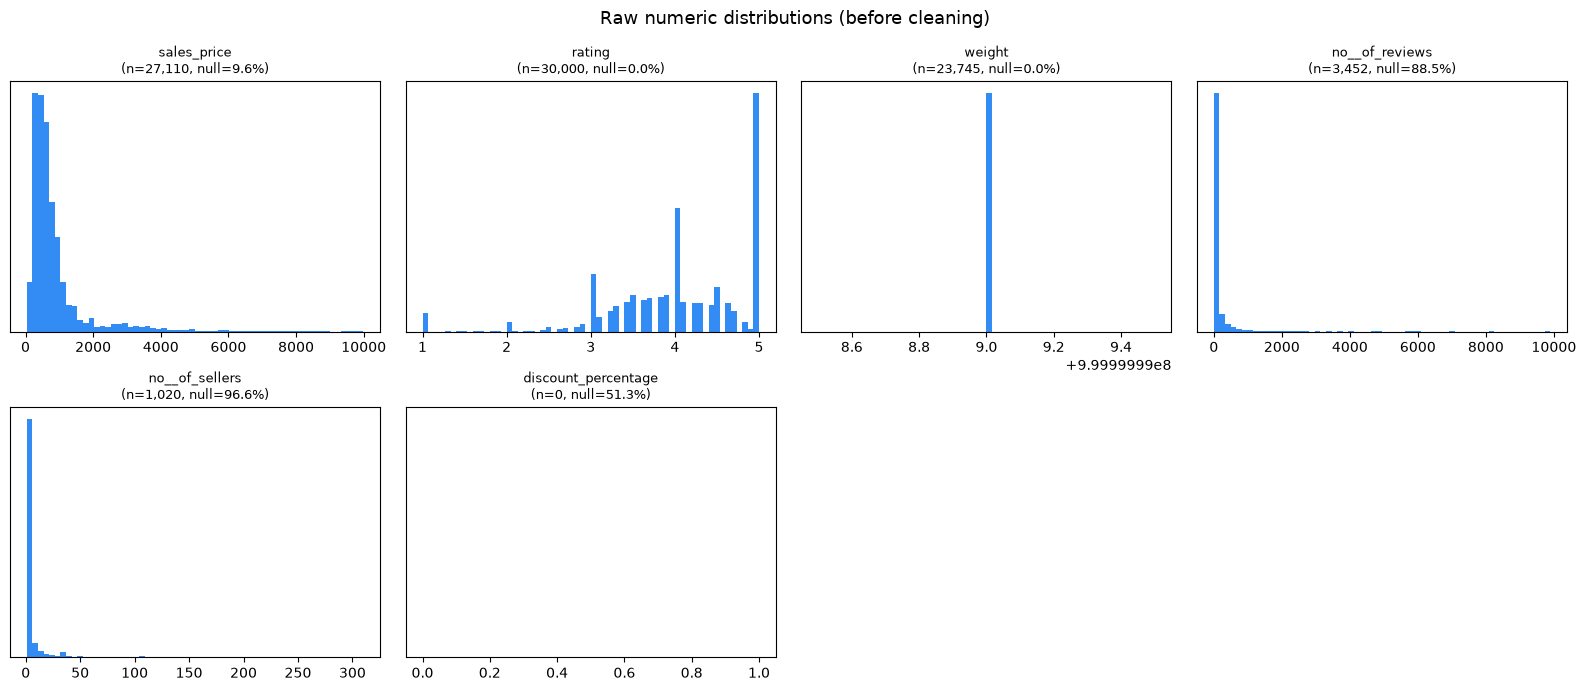

In [7]:
numeric_cols = [c for c in numeric_candidates if c in df.columns]
print(f"Found columns: {numeric_cols}")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
fig.suptitle("Raw numeric distributions (before cleaning)", fontsize=13)

for i, col in enumerate(numeric_cols):
    vals = pd.to_numeric(df[col], errors="coerce").dropna()
    axes[i].hist(vals, bins=60, color="#0070F2", alpha=0.8)
    axes[i].set_title(f"{col}\n(n={len(vals):,}, null={df[col].isna().mean():.1%})", fontsize=9)
    axes[i].set_yticks([])

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [8]:
weight_raw = pd.to_numeric(df["weight"], errors="coerce")
print("weight — descriptive stats:")
print(weight_raw.describe())
print(f"\nValues >= 1,000,000: {(weight_raw >= 1_000_000).sum():,}")
print(f"Values >= 999,999,999: {(weight_raw >= 999_999_999).sum():,}")
print(f"\nTop 10 weight values:")
print(weight_raw.value_counts().head(10))

weight — descriptive stats:
count        23745.0
mean     999999999.0
std              0.0
min      999999999.0
25%      999999999.0
50%      999999999.0
75%      999999999.0
max      999999999.0
Name: weight, dtype: float64

Values >= 1,000,000: 23,745
Values >= 999,999,999: 23,745

Top 10 weight values:
weight
999999999.0    23745
Name: count, dtype: int64


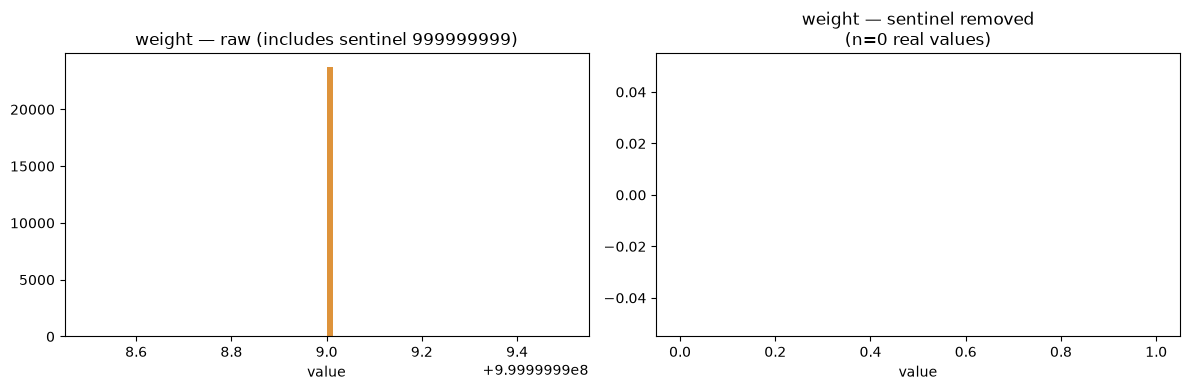


Sentinel (999999999) accounts for 100.0% of non-null weight values
→ After replacing with NaN, the column will be 100% null and gets dropped from features


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(weight_raw.dropna(), bins=80, color="#D6780A", alpha=0.8)
axes[0].set_title("weight — raw (includes sentinel 999999999)")
axes[0].set_xlabel("value")

real_weights = weight_raw[weight_raw < 1_000_000].dropna()
axes[1].hist(real_weights, bins=80, color="#188918", alpha=0.8)
axes[1].set_title(f"weight — sentinel removed\n(n={len(real_weights):,} real values)")
axes[1].set_xlabel("value")

plt.tight_layout()
plt.show()

print(f"\nSentinel (999999999) accounts for {(weight_raw >= 999_999_999).sum() / weight_raw.notna().sum():.1%} of non-null weight values")
print("→ After replacing with NaN, the column will be 100% null and gets dropped from features")

In [10]:
cat_candidates = ["brand", "colour", "product_rating", "category"]

In [11]:
cat_cols = [c for c in cat_candidates if c in df.columns]
print(f"Found columns: {cat_cols}")

for col in cat_cols:
    n_unique = df[col].nunique()
    null_pct = df[col].isna().mean()
    top5     = df[col].value_counts().head(5)
    print(f"\n{col}  (unique={n_unique:,}, null={null_pct:.1%})")
    print(top5.to_string())


Found columns: ['brand', 'colour']

brand  (unique=6,458, null=27.1%)
brand
Max             504
Generic         245
BIBA            205
Mothercare      156
Campus Sutra    150

colour  (unique=4,757, null=79.9%)
colour
Black|White    79
Black|Blue     45
Black|Red      34
Black|Navy     31
Blue|Red       30


In [12]:
top_brands = df["brand"].value_counts().head(20)

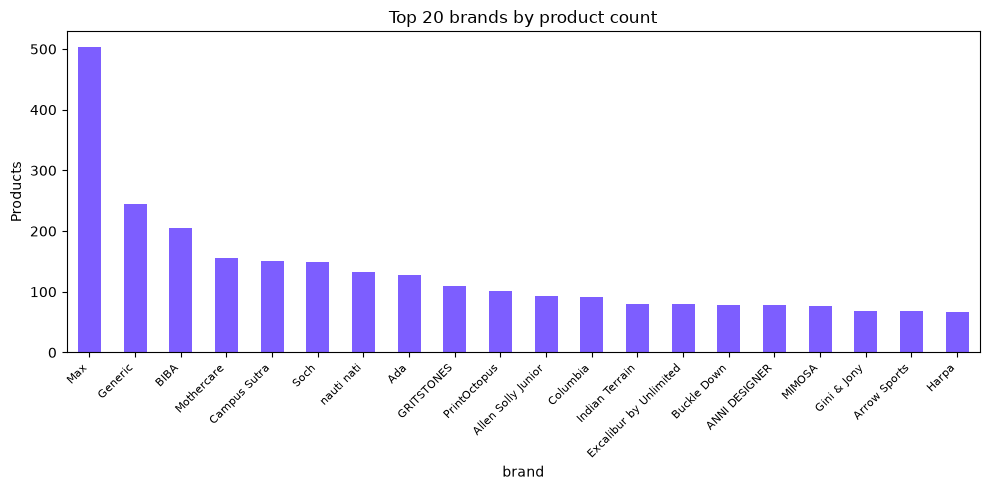

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
top_brands.plot(kind="bar", ax=ax, color="#5D36FF", alpha=0.8)
ax.set_title("Top 20 brands by product count")
ax.set_ylabel("Products")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

Found columns: ['product_name', 'meta_keywords']


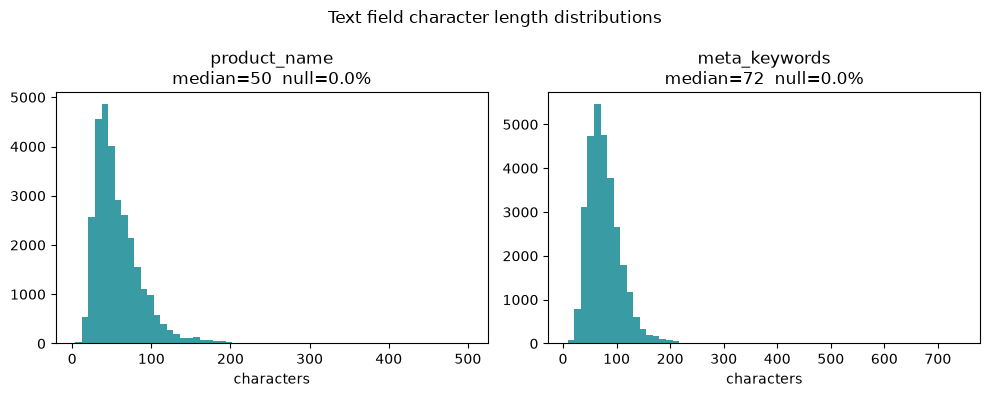

In [14]:
text_candidates = ["product_name", "meta_keywords", "description", "about_product"]

text_cols = [c for c in text_candidates if c in df.columns]
print(f"Found columns: {text_cols}")

fig, axes = plt.subplots(1, len(text_cols), figsize=(5 * len(text_cols), 4))
if len(text_cols) == 1:
    axes = [axes]
fig.suptitle("Text field character length distributions")

for i, col in enumerate(text_cols):
    lengths = df[col].fillna("").astype(str).str.len()
    axes[i].hist(lengths, bins=60, color="#07838F", alpha=0.8)
    axes[i].set_title(f"{col}\nmedian={lengths.median():.0f}  null={df[col].isna().mean():.1%}")
    axes[i].set_xlabel("characters")

plt.tight_layout()
plt.show()

In [15]:
sample_cats = df["parent___child_category__all"].dropna().head(5)
for i, val in enumerate(sample_cats):
    print(f"[{i}] type={type(val).__name__}  value={str(val)[:120]}")


[0] type=dict  value={'ClothingAccessories': '#19,259', 'WomensKurtasKurtis': '#1793'}
[1] type=dict  value={'ClothingAccessories': '#1,59,062', 'MensT_Shirts': '#12151'}
[2] type=dict  value={'ClothingAccessories': '#1,050', 'WomensKurtasKurtis': '#91'}
[3] type=dict  value={'ClothingAccessories': '#2,47,234', 'MensT_Shirts': '#19368'}
[4] type=dict  value={'ClothingAccessories': '#13,980', 'MensTracksuits': '#12'}


In [16]:
type_counts = df["parent___child_category__all"].apply(lambda x: type(x).__name__).value_counts()
print("parent___child_category__all value types:")
print(type_counts)


parent___child_category__all value types:
parent___child_category__all
dict     25497
float     4503
Name: count, dtype: int64


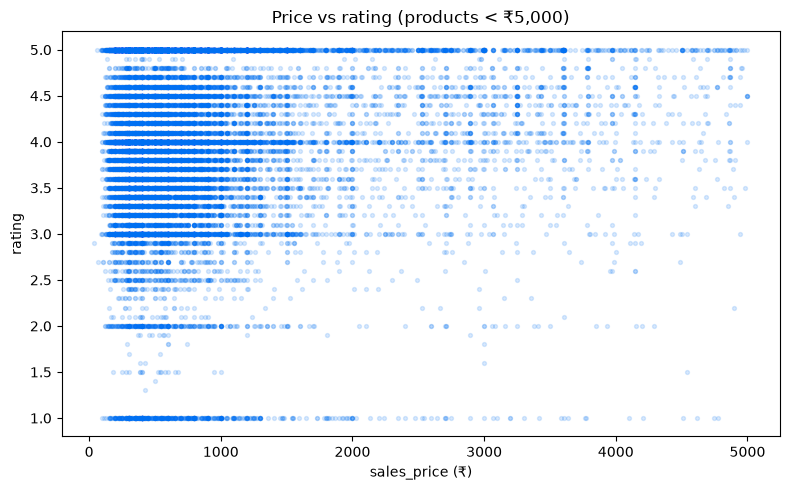

Correlation (price vs rating): 0.088


In [17]:
price  = pd.to_numeric(df["sales_price"], errors="coerce")
rating = pd.to_numeric(df["rating"], errors="coerce")

mask = price.notna() & rating.notna() & (price < 5000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(price[mask], rating[mask], alpha=0.15, s=8, color="#0070F2")
ax.set_xlabel("sales_price (₹)")
ax.set_ylabel("rating")
ax.set_title("Price vs rating (products < ₹5,000)")
plt.tight_layout()
plt.show()

print(f"Correlation (price vs rating): {price[mask].corr(rating[mask]):.3f}")


In [1]:
import pandas as pd
df = pd.read_json("../data/marketing_sample_for_amazon_com-amazon_fashion_products__20200201_20200430__30k_data.ldjson", lines=True)
print(sorted(df.columns.tolist()))


['amazon_prime__y_or_n', 'asin', 'best_seller_tag__y_or_n', 'brand', 'browsenode', 'colour', 'crawl_timestamp', 'delivery_type', 'discount_percentage', 'formats___editions', 'image_urls__small', 'large', 'left_in_stock', 'medium', 'meta_keywords', 'name_of_author_for_books', 'no__of_offers', 'no__of_reviews', 'no__of_sellers', 'other_items_customers_buy', 'parent___child_category__all', 'product_details__k_v_pairs', 'product_name', 'product_url', 'rating', 'sales_price', 'sales_rank_in_child_category', 'sales_rank_in_parent_category', 'seller_id', 'seller_name', 'technical_details__k_v_pairs', 'uniq_id', 'weight']
